In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data.csv')
df.head()

,km,price
0,240000,3650
1,139800,3800
2,150500,4400
3,185530,4450
4,176000,5250


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   km      24 non-null     int64
 1   price   24 non-null     int64
dtypes: int64(2)
memory usage: 516.0 bytes


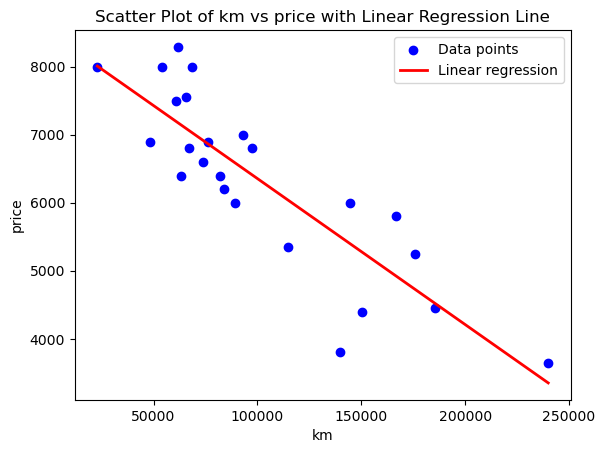

In [ ]:
import json
import numpy as np

df = pd.read_csv('data.csv')

# Load the trained thetas
try:
    with open("thetas.json", "r") as f:
        res = json.load(f)
        t0, t1 = res["t0"], res["t1"]
        min_m, max_m = res["min"], res["max"]
    
    # Create data points for the regression line
    km_range = np.linspace(df['km'].min(), df['km'].max(), 100)
    
    # Normalize the km values using the same scaling as training
    norm_km_range = (km_range - min_m) / (max_m - min_m)
    
    # Calculate predicted prices using the trained model
    predicted_prices = t0 + (t1 * norm_km_range)
    
    # Create the plot
    plt.scatter(df['km'], df['price'], color='blue', label='Data points')
    plt.plot(km_range, predicted_prices, color='red', linewidth=2, label='Linear regression')
    
    plt.xlabel('km')
    plt.ylabel('price')
    plt.title('Scatter Plot of km vs price with Linear Regression Line')
    plt.legend()
    plt.show()
    
except FileNotFoundError:
    print("thetas.json not found. Run train.py first to generate the model.")
    # Show scatter plot without regression line
    plt.scatter(df['km'], df['price'])
    plt.xlabel('km')
    plt.ylabel('price')
    plt.title('Scatter Plot of km vs price')
    plt.show()